# Tutorial 13 — Synthetic Fibrous-Tissue Generation

This notebook generates transparent 2-D and 3-D fibrous architectures with explicit ground truth. All examples are synthetic.

In [1]:
LANGUAGE = "en"
from pathlib import Path
import sys


def _find_repository_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Repository root not found. Open the notebook inside the repository.")


REPOSITORY_ROOT = _find_repository_root(Path.cwd().resolve())
SOURCE_DIRECTORY = REPOSITORY_ROOT / "src"
if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))

import biomechanics_tutorials
import matplotlib.pyplot as plt
import numpy as np
from biomechanics_tutorials.synthetic_fibrous_tissue import (
    add_branches,
    export_network_dataset,
    generate_crossing_families,
    generate_fiber_volume,
    generate_mikado_network,
    morphological_skeleton,
    network_metrics,
    rasterize_network,
    skeleton_graph_metrics,
    tissue_preset,
)


def tr(en, ru):
    return en if LANGUAGE == "en" else ru

print(tr("Repository", "Репозиторий"), REPOSITORY_ROOT)
print("Package:", Path(biomechanics_tutorials.__file__).resolve())

Repository /mnt/data/Biomechanics-Research-Tutorials
Package: /mnt/data/Biomechanics-Research-Tutorials/src/biomechanics_tutorials/__init__.py


## 1. Universal presets

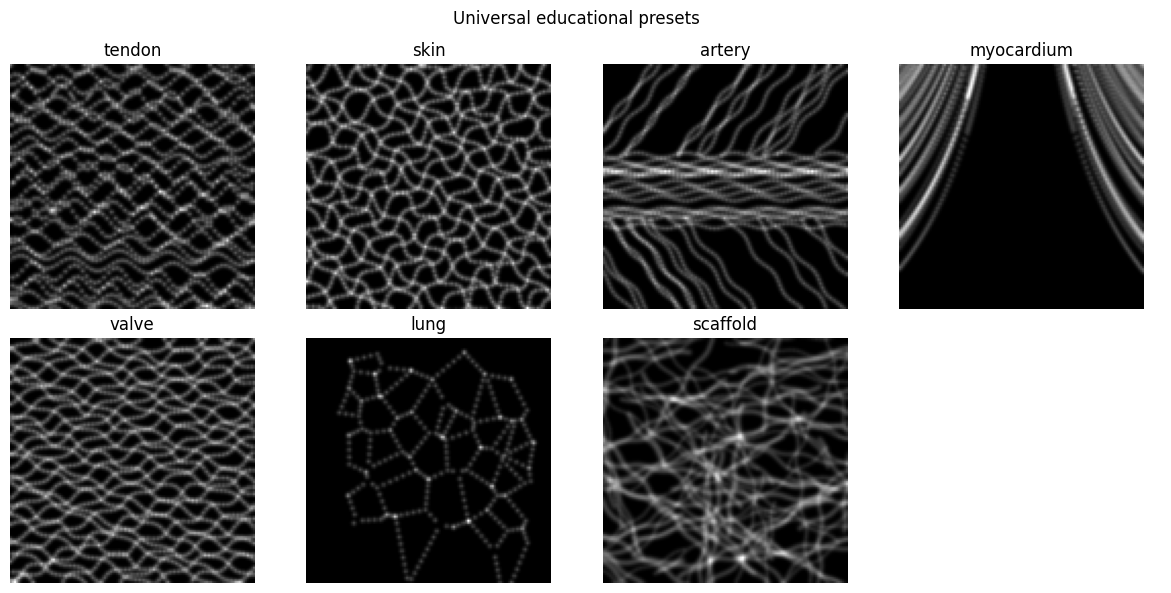

In [2]:
names = ["tendon", "skin", "artery", "myocardium", "valve", "lung", "scaffold"]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for axis, name in zip(axes.flat, names):
    network = tissue_preset(name, seed=10)
    raster = rasterize_network(network, (120, 120))
    axis.imshow(raster.image, cmap="gray")
    axis.set_title(name)
    axis.axis("off")
axes.flat[-1].axis("off")
fig.suptitle(tr("Universal educational presets", "Универсальные учебные пресеты"))
plt.tight_layout()
plt.show()

## 2. Synchronized ground truth

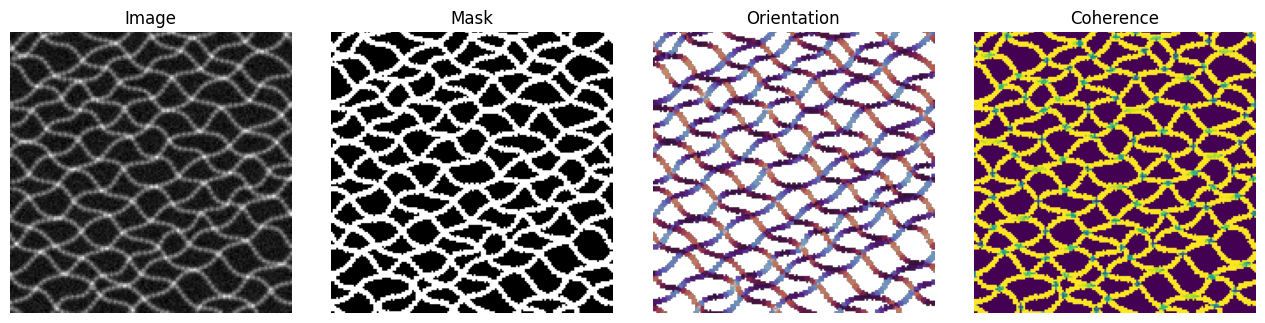

In [3]:
network = generate_crossing_families((-0.55, 0.55), n_per_family=18, seed=21)
raster = rasterize_network(network, (160, 160), noise_std=0.02)
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
axes[0].imshow(raster.image, cmap="gray")
axes[0].set_title(tr("Image", "Изображение"))
axes[1].imshow(raster.mask, cmap="gray")
axes[1].set_title(tr("Mask", "Маска"))
axes[2].imshow(
    np.rad2deg(raster.orientation), cmap="twilight", vmin=-90, vmax=90
)
axes[2].set_title(tr("Orientation", "Ориентация"))
axes[3].imshow(raster.coherence, cmap="viridis", vmin=0, vmax=1)
axes[3].set_title(tr("Coherence", "Когерентность"))
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()


## 3. Density and topology

In [4]:
for count in (20, 45, 80):
    network = generate_mikado_network(count, concentration=0.8, seed=32)
    raster = rasterize_network(network, (128, 128), blur_sigma=0.0)
    metrics = network_metrics(network, raster)
    print(count, {key: round(value, 4) if isinstance(value, float) else value for key, value in metrics.items() if key in {"porosity", "order_parameter", "components", "largest_component_fraction"}})

20 {'porosity': 0.744, 'order_parameter': 0.359, 'components': 90, 'largest_component_fraction': 0.17}
45 {'porosity': 0.5792, 'order_parameter': 0.5367, 'components': 140, 'largest_component_fraction': 0.1207}


80 {'porosity': 0.3135, 'order_parameter': 0.5721, 'components': 225, 'largest_component_fraction': 0.0392}


## 4. Crossing-family ambiguity

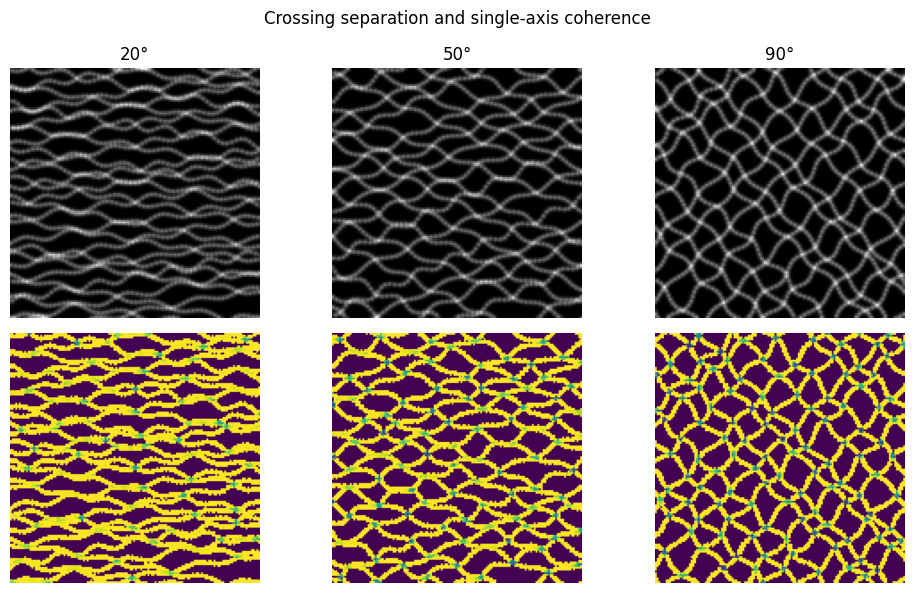

In [5]:
separations = (20, 50, 90)
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for column, separation in enumerate(separations):
    half = np.deg2rad(separation / 2)
    network = generate_crossing_families((-half, half), 18, seed=40 + column)
    raster = rasterize_network(network, (140, 140))
    axes[0, column].imshow(raster.image, cmap="gray")
    axes[0, column].set_title(f"{separation}°")
    axes[1, column].imshow(raster.coherence, cmap="viridis", vmin=0, vmax=1)
    for row in range(2):
        axes[row, column].axis("off")
fig.suptitle(
    tr(
        "Crossing separation and single-axis coherence",
        "Разведение семейств и одноосевая когерентность",
    )
)
plt.tight_layout()
plt.show()


## 5. Skeleton metrics

{'components': 208, 'endpoints': 273, 'branchpoints': 1153, 'nodes': 1426, 'skeleton_pixels': 2384, 'largest_component_pixels': 129, 'largest_component_fraction': 0.054110738255033555}


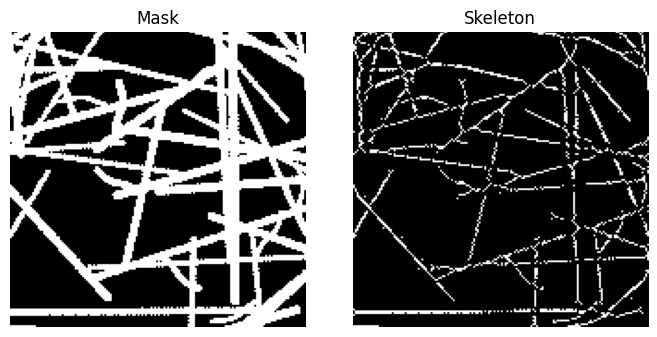

In [6]:
network = add_branches(
    generate_mikado_network(45, seed=52),
    branch_probability=0.4,
    seed=53,
)
raster = rasterize_network(network, (160, 160), blur_sigma=0.0)
skeleton = morphological_skeleton(raster.mask)
print(skeleton_graph_metrics(skeleton))
fig, axes = plt.subplots(1, 2, figsize=(7, 3.4))
axes[0].imshow(raster.mask, cmap="gray")
axes[0].set_title(tr("Mask", "Маска"))
axes[1].imshow(skeleton, cmap="gray")
axes[1].set_title(tr("Skeleton", "Скелет"))
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()


## 6. Three-dimensional volume

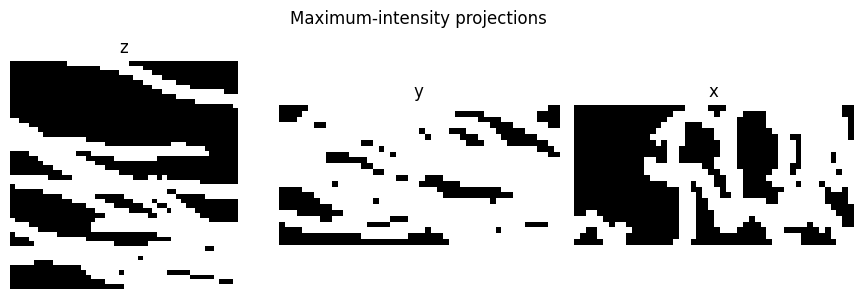

In [7]:
volume = generate_fiber_volume(
    (24, 48, 48),
    n_fibers=14,
    mean_direction=(0.2, 0.1, 1.0),
    seed=64,
)
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
projections = [
    volume.volume.max(axis=0),
    volume.volume.max(axis=1),
    volume.volume.max(axis=2),
]
for axis, projection, label in zip(axes, projections, ["z", "y", "x"]):
    axis.imshow(projection, cmap="gray")
    axis.set_title(label)
    axis.axis("off")
fig.suptitle(
    tr("Maximum-intensity projections", "Проекции максимальной интенсивности")
)
plt.tight_layout()
plt.show()


## 7. Dataset export

In [8]:
output = REPOSITORY_ROOT / "tutorials" / "13-synthetic-fibrous-tissue-generation" / "data" / "notebook_example_dataset.npz"
network = tissue_preset("skin", seed=75)
raster = rasterize_network(network, (128, 128), noise_std=0.01)
export_network_dataset(output, network, raster)
print(tr("Saved", "Сохранено"), output)

Saved /mnt/data/Biomechanics-Research-Tutorials/tutorials/13-synthetic-fibrous-tissue-generation/data/notebook_example_dataset.npz


## Interpretation

The generated objects are verification-ready synthetic examples. Preset names indicate qualitative architecture only and do not establish experimental validity.